In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import Normalizer
from sklearn.pipeline import Pipeline
from sklearn.pipeline import make_pipeline
from sklearn.compose import make_column_transformer
from sklearn.linear_model import RidgeClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.model_selection import train_test_split
from sklearn.model_selection import cross_val_score
from sklearn.metrics import mean_squared_error
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.feature_extraction.text import TfidfTransformer
from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report
from sklearn.metrics import ConfusionMatrixDisplay
from sklearn.metrics import f1_score
import spacy
import gensim
import nltk
from nltk.stem import WordNetLemmatizer

nltk.download('wordnet')

[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


True

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
users_code_location_df = pd.read_csv('/content/drive/MyDrive/thesis/part2 feature-creation/2.1 feature creation/code_sections_extracts.csv')

users_code_location_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 24 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   Username                     2000 non-null   object 
 1   Display_Name                 2000 non-null   object 
 2   Gender                       2000 non-null   object 
 3   notebook_url                 2000 non-null   object 
 4   code_location                2000 non-null   object 
 5   labels                       2000 non-null   object 
 6   top_labels                   2000 non-null   object 
 7   code_sections                2000 non-null   object 
 8   markdown_sections            2000 non-null   object 
 9   all_sections                 2000 non-null   object 
 10  only_code_in_code_sections   2000 non-null   object 
 11  number_of_lines              2000 non-null   float64
 12  names_set                    2000 non-null   object 
 13  num_of_sections   

In [ ]:
users_code_location_df.head()

,Username,Display_Name,Gender,notebook_url,code_location,labels,top_labels,code_sections,markdown_sections,all_sections,...,token_count,variables_count,function_count,loop_count,condition_count,single_line_comment_density,function_density,loop_density,condition_density,comment_tokens_density
0,tchaye59,Jude TCHAYE,male,https://www.kaggle.com/code/tchaye59/jmarket-k...,/content/drive/MyDrive/thesis/notebooks/male/t...,"['Jane Street Market Prediction', 'Jane Street...",{'Jane Street Market Prediction'},['# This Python 3 environment comes with many ...,['### This notebook is only dedicated to submi...,['# This Python 3 environment comes with many ...,...,155,30,0,3,0,0.333333,0.000000,0.019355,0.000000,0.524272
1,iyara1,Riya,female,https://www.kaggle.com/code/iyara1/deepanalysi...,/content/drive/MyDrive/thesis/notebooks/female...,['House Prices - Advanced Regression Techniques'],{'House Prices - Advanced Regression Techniques'},"[""import numpy as np\nimport pandas as pd\nimp...",['**#Bivariate Analysis******'],"[""import numpy as np\nimport pandas as pd\nimp...",...,374,102,1,7,7,0.129825,0.002674,0.018717,0.018717,0.359568
2,sanjay7013,Sanjay M,male,https://www.kaggle.com/code/sanjay7013/credit-...,/content/drive/MyDrive/thesis/notebooks/male/s...,['Credit Card Fraud Detection'],{'Credit Card Fraud Detection'},['# This Python 3 environment comes with many ...,"['# Credit Card Fraud Detection', ""### DataSet...","['# Credit Card Fraud Detection', ""### DataSet...",...,206,65,0,2,0,0.166667,0.000000,0.009709,0.000000,0.386076
3,validmodel,Rashmi Margani,female,https://www.kaggle.com/code/validmodel/master-...,/content/drive/MyDrive/thesis/notebooks/female...,['Iris Species'],{'Iris Species'},['# This Python 3 environment comes with many ...,"[""# <h1 style='background:#f0c2c1; border:2; b...",['# This Python 3 environment comes with many ...,...,302,95,12,9,12,0.159420,0.039735,0.029801,0.039735,0.279314
4,rajeevnair676,Rajeev Nair,male,https://www.kaggle.com/code/rajeevnair676/nlp-...,/content/drive/MyDrive/thesis/notebooks/male/r...,"['IMDB Dataset of 50K Movie Reviews', 'Tweet S...",{'Natural Language Processing with Disaster Tw...,['#Importing NLTK package\nimport nltk\n\nimpo...,['# <center><b> NLP STARTERS - PART 1 <center/...,['# <center><b> NLP STARTERS - PART 1 <center/...,...,197,63,5,17,3,0.095652,0.025381,0.086294,0.015228,0.193370


In [ ]:
X=users_code_location_df.drop('Gender',axis=1)
Y=users_code_location_df.Gender.map({"male": 1, "female": 0})

In [ ]:
X.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 23 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   Username                     2000 non-null   object 
 1   Display_Name                 2000 non-null   object 
 2   notebook_url                 2000 non-null   object 
 3   code_location                2000 non-null   object 
 4   labels                       2000 non-null   object 
 5   top_labels                   2000 non-null   object 
 6   code_sections                2000 non-null   object 
 7   markdown_sections            2000 non-null   object 
 8   all_sections                 2000 non-null   object 
 9   only_code_in_code_sections   2000 non-null   object 
 10  number_of_lines              2000 non-null   float64
 11  names_set                    2000 non-null   object 
 12  num_of_sections              2000 non-null   int64  
 13  token_count       

# Non text features

In [ ]:
X_nontext=X[['number_of_lines','num_of_sections', 'token_count', 'variables_count',
            'function_count', 'loop_count', 'condition_count',
            'single_line_comment_density', 'function_density', 'loop_density',
            'condition_density', 'comment_tokens_density']]
X_nontext.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 12 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   number_of_lines              2000 non-null   float64
 1   num_of_sections              2000 non-null   int64  
 2   token_count                  2000 non-null   int64  
 3   variables_count              2000 non-null   int64  
 4   function_count               2000 non-null   int64  
 5   loop_count                   2000 non-null   int64  
 6   condition_count              2000 non-null   int64  
 7   single_line_comment_density  2000 non-null   float64
 8   function_density             2000 non-null   float64
 9   loop_density                 2000 non-null   float64
 10  condition_density            2000 non-null   float64
 11  comment_tokens_density       2000 non-null   float64
dtypes: float64(6), int64(6)
memory usage: 187.6 KB


In [ ]:
X_train_nontext, X_test_nontext, y_train, y_test = train_test_split(X_nontext, Y, test_size=0.25, random_state=0,stratify=Y)

In [ ]:
baseline_model = Pipeline([('scaler',StandardScaler()),
                           ('classifier',RidgeClassifier())])

In [ ]:
scores = cross_val_score(baseline_model, X_train_nontext, y_train, cv=5)
print("baseline model score: ",np.mean(scores))

baseline model score:  0.568


In [ ]:
param_grid = [{'classifier__alpha': np.logspace(0,3,16)}]
ridge_cv= GridSearchCV(baseline_model, param_grid,cv=5,return_train_score=True)
ridge_cv.fit(X_train_nontext, y_train)
print("nontext grid ridge train score ",ridge_cv.score(X_train_nontext, y_train))
print("nontext grid ridge test score ",ridge_cv.score(X_test_nontext, y_test))
print("nontext Ridge classifier train mse score ",mean_squared_error(y_train,ridge_cv.predict(X_train_nontext)))
print("nontext Ridge classifier test mse score ",mean_squared_error(y_test,ridge_cv.predict(X_test_nontext)))
ridge_cv.best_params_

nontext grid ridge train score  0.578
nontext grid ridge test score  0.594
nontext Ridge classifier train mse score  0.422
nontext Ridge classifier test mse score  0.422


{'classifier__alpha': 63.09573444801933}

# simple BOW

In [ ]:
X['parsed_code'] = X.code_sections.apply(eval).str.join('\n')

In [ ]:
X_train_text, X_test_text, y_train, y_test = train_test_split(X.parsed_code, Y, test_size=0.25, random_state=0,stratify=Y)

In [ ]:
#create BOW
custom_token_pattern = r'\b[A-Za-z_]\w*\b'

# Initialize CountVectorizer with the custom token pattern
vect = CountVectorizer(stop_words='english', min_df=100, token_pattern=custom_token_pattern)
X_train_simple=vect.fit_transform(X_train_text)
X_test_simple=vect.transform(X_test_text)
print(vect.get_feature_names_out())

['_' '__init__' 'abs' 'accuracy' 'accuracy_score' 'activation' 'adam'
 'add' 'advanced' 'age' 'algebra' 'alpha' 'analytics' 'annot' 'append'
 'apply' 'arange' 'argmax' 'array' 'ascending' 'astype' 'auc' 'auto'
 'available' 'average' 'ax' 'axes' 'axis' 'b' 'bar' 'barplot' 'base'
 'batch' 'batch_size' 'best' 'best_params_' 'binary' 'binary_crossentropy'
 'bins' 'black' 'blue' 'boxplot' 'c' 'cabin' 'calculate' 'callbacks'
 'capt' 'cat' 'categorical' 'category' 'center' 'check' 'checking' 'class'
 'classes' 'classification' 'classification_report' 'classifier' 'clf'
 'clicking' 'cm' 'cmap' 'code' 'col' 'collections' 'color' 'cols' 'column'
 'columns' 'com' 'comes' 'compile' 'concat' 'confusion' 'confusion_matrix'
 'conv2d' 'convert' 'copy' 'corr' 'correlation' 'count' 'countess'
 'countplot' 'create' 'creating' 'criterion' 'cross' 'cross_val_score'
 'csv' 'current' 'cv' 'd' 'data' 'dataframe' 'dataset' 'datasets'
 'decision' 'decisiontreeclassifier' 'def' 'define' 'defined' 'del'
 'dense' 

In [ ]:
ridge = RidgeClassifier().fit(X_train_simple, y_train)
print("simple BOW Ridge Classifier train score ",ridge.score(X_train_simple, y_train))
print("simple BOW Ridge Classifier test score ",ridge.score(X_test_simple, y_test))
print("simple BOW Ridge Classifier train mse score ",mean_squared_error(y_train,ridge.predict(X_train_simple)))
print("simple BOW Ridge Classifier test mse score ",mean_squared_error(y_test,ridge.predict(X_test_simple)))

simple BOW Ridge Classifier train score  0.794
simple BOW Ridge Classifier test score  0.606
simple BOW Ridge Classifier train mse score  0.206
simple BOW Ridge Classifier test mse score  0.394


In [ ]:
def plot_important_features(coef, feature_names, top_n=20, ax=None, rotation=60):
    if ax is None:
         ax = plt.gca()
    inds = np.argsort(coef)
    low = inds[:top_n]
    high = inds[-top_n:]
    important = np.hstack([low, high])
    myrange = range(len(important))
    colors = ['red'] * top_n + ['blue'] * top_n
    ax.bar(myrange, coef[important], color=colors)
    ax.set_xticks(myrange)
    ax.set_xticklabels(feature_names[important], rotation=rotation, ha="right")
    ax.set_xlim(-.7, 2 * top_n)
    ax.set_frame_on(False)

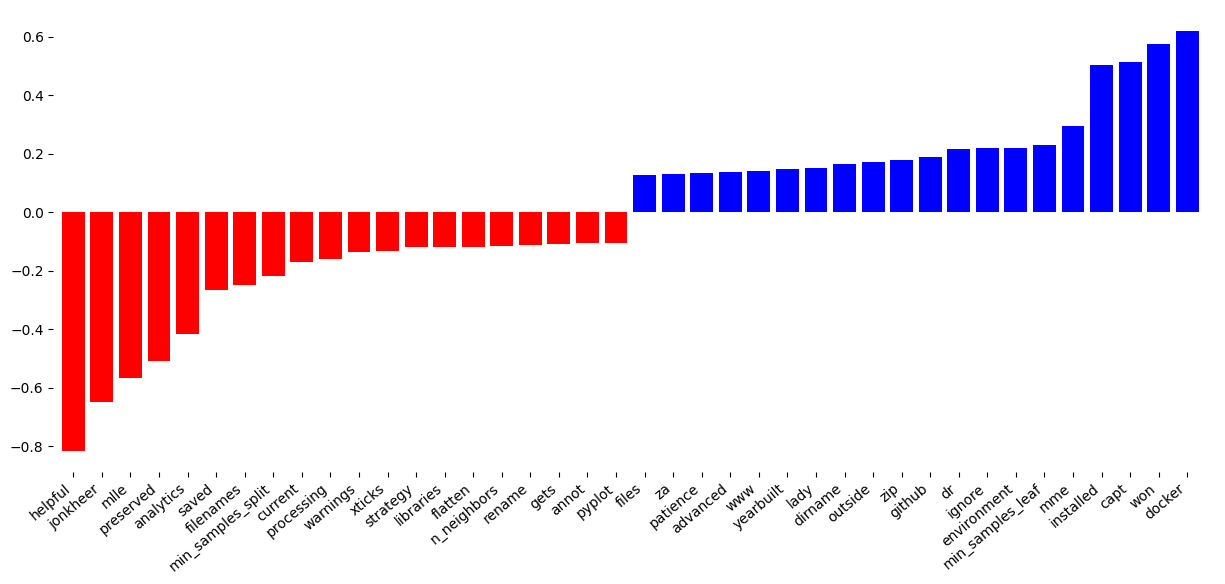

In [ ]:
plt.figure(figsize=(15, 6))
plot_important_features(ridge.coef_.ravel(), vect.get_feature_names_out(), top_n=20, rotation=40)
ax = plt.gca()
plt.show()

# n-grams tf-idf

In [ ]:
wordnet_lem = WordNetLemmatizer()

X_train_lemma=X_train_text.apply(wordnet_lem.lemmatize)
X_test_lemma=X_test_text.apply(wordnet_lem.lemmatize)

In [ ]:
tfidf_pipeline = make_pipeline(CountVectorizer(stop_words='english',ngram_range=(2,10),min_df=100),
                      Normalizer(),
                      TfidfTransformer(),
                      RidgeClassifier(random_state=0),memory="cache_folder")

In [ ]:
param_grid = [{
    'countvectorizer__ngram_range':[(2, 5), (3, 6), (4,8), (5,9), (2,10)],
    'ridgeclassifier__alpha':np.logspace(-2,2,20)}]

ridge_cv= GridSearchCV(tfidf_pipeline, param_grid,cv=5,return_train_score=True)

ridge_cv.fit(X_train_lemma, y_train)

print("n-grams grid ridge train score ",ridge_cv.score(X_train_lemma, y_train))
print("n-grams grid ridge test score ",ridge_cv.score(X_test_lemma, y_test))
print("n-grams Ridge classifier train mse score ",mean_squared_error(y_train,ridge_cv.predict(X_train_lemma)))
print("n-grams Ridge classifier test mse score ",mean_squared_error(y_test,ridge_cv.predict(X_test_lemma)))
ridge_cv.best_params_

n-grams grid ridge train score  0.696
n-grams grid ridge test score  0.62
n-grams Ridge classifier train mse score  0.304
n-grams Ridge classifier test mse score  0.38


{'countvectorizer__ngram_range': (2, 3),
 'ridgeclassifier__alpha': 5.455594781168514}

              precision    recall  f1-score   support

           0       0.60      0.53      0.57       232
           1       0.63      0.69      0.66       268

    accuracy                           0.62       500
   macro avg       0.62      0.61      0.61       500
weighted avg       0.62      0.62      0.62       500

f1_score :  0.6619217081850535


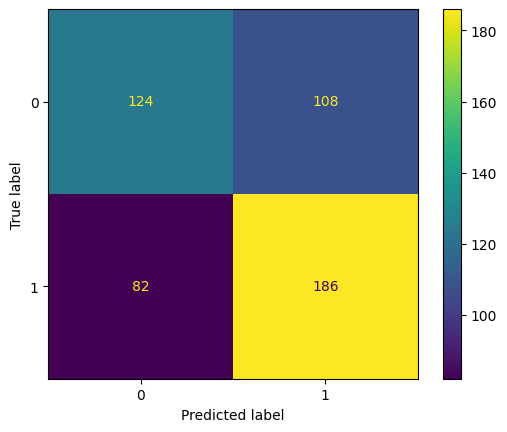

In [ ]:
y_pred_test = ridge_cv.predict(X_test_lemma)

print(classification_report(y_test, y_pred_test))

print("f1_score : ",f1_score(y_test, y_pred_test))

disp = ConfusionMatrixDisplay(confusion_matrix=confusion_matrix(y_test, y_pred_test))

disp.plot()

plt.show()

In [ ]:
results = pd.DataFrame(ridge_cv.cv_results_)
results.head(10)

,mean_fit_time,std_fit_time,mean_score_time,std_score_time,param_countvectorizer__ngram_range,param_ridgeclassifier__alpha,params,split0_test_score,split1_test_score,split2_test_score,...,mean_test_score,std_test_score,rank_test_score,split0_train_score,split1_train_score,split2_train_score,split3_train_score,split4_train_score,mean_train_score,std_train_score
0,2.387590,1.412011,0.333533,0.135338,"(1, 1)",0.01,"{'countvectorizer__ngram_range': (1, 1), 'ridg...",0.600000,0.573333,0.550000,...,0.565333,0.019619,84,0.806667,0.815833,0.817500,0.800833,0.825000,0.813167,0.008489
1,0.272197,0.060707,0.293016,0.088505,"(1, 1)",0.016238,"{'countvectorizer__ngram_range': (1, 1), 'ridg...",0.593333,0.573333,0.560000,...,0.566667,0.015348,81,0.805833,0.815833,0.818333,0.800000,0.823333,0.812667,0.008521
2,0.207875,0.008607,0.219361,0.012516,"(1, 1)",0.026367,"{'countvectorizer__ngram_range': (1, 1), 'ridg...",0.590000,0.580000,0.556667,...,0.565333,0.016680,86,0.805000,0.811667,0.815833,0.800833,0.816667,0.810000,0.006169
3,0.261678,0.117347,0.318543,0.097037,"(1, 1)",0.042813,"{'countvectorizer__ngram_range': (1, 1), 'ridg...",0.586667,0.576667,0.533333,...,0.558667,0.019844,92,0.804167,0.805000,0.805833,0.799167,0.810833,0.805000,0.003727
4,0.187166,0.004613,0.221597,0.010755,"(1, 1)",0.069519,"{'countvectorizer__ngram_range': (1, 1), 'ridg...",0.593333,0.580000,0.536667,...,0.560667,0.023514,91,0.800833,0.802500,0.806667,0.794167,0.803333,0.801500,0.004130
5,0.203084,0.037574,0.258961,0.076060,"(1, 1)",0.112884,"{'countvectorizer__ngram_range': (1, 1), 'ridg...",0.593333,0.583333,0.533333,...,0.565333,0.026382,84,0.795000,0.798333,0.806667,0.798333,0.800000,0.799667,0.003859
6,0.174631,0.004351,0.220889,0.008185,"(1, 1)",0.183298,"{'countvectorizer__ngram_range': (1, 1), 'ridg...",0.590000,0.600000,0.536667,...,0.573333,0.026247,73,0.779167,0.788333,0.802500,0.795833,0.795833,0.792333,0.007965
7,0.204537,0.042564,0.295883,0.094347,"(1, 1)",0.297635,"{'countvectorizer__ngram_range': (1, 1), 'ridg...",0.603333,0.603333,0.536667,...,0.579333,0.027520,64,0.765000,0.780000,0.792500,0.785833,0.782500,0.781167,0.009107
8,0.165166,0.006037,0.220314,0.012647,"(1, 1)",0.483293,"{'countvectorizer__ngram_range': (1, 1), 'ridg...",0.593333,0.623333,0.553333,...,0.587333,0.024801,34,0.757500,0.767500,0.784167,0.776667,0.765000,0.770167,0.009301
9,0.176088,0.036103,0.258497,0.081029,"(1, 1)",0.78476,"{'countvectorizer__ngram_range': (1, 1), 'ridg...",0.603333,0.626667,0.533333,...,0.586667,0.031623,35,0.746667,0.749167,0.766667,0.764167,0.749167,0.755167,0.008456


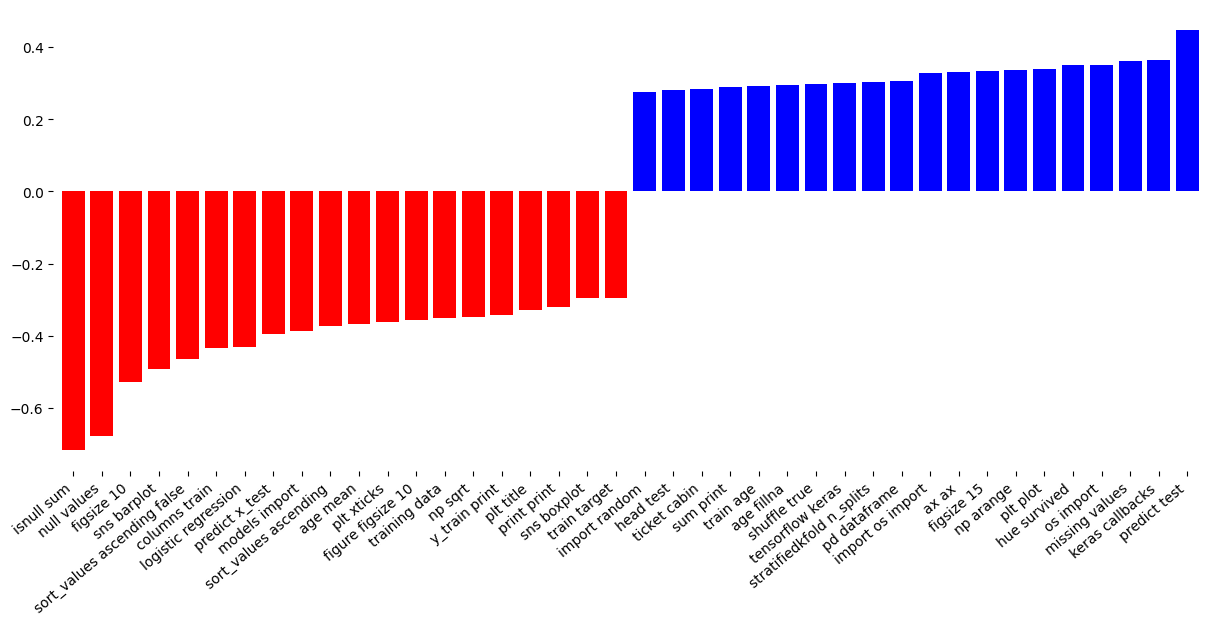

In [ ]:
plt.figure(figsize=(15, 6))
plot_important_features(ridge_cv.best_estimator_.named_steps.ridgeclassifier.coef_.ravel(), ridge_cv.best_estimator_[:-1].get_feature_names_out(), top_n=20, rotation=40)
ax = plt.gca()
plt.show()

#Pretrained Work Vectors

In [ ]:
%%python -m spacy download en_core_web_lg

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 587.7/587.7 MB 1.9 MB/s eta 0:00:00
✔ Download and installation successful
You can now load the package via spacy.load('en_core_web_lg')
⚠ Restart to reload dependencies
If you are in a Jupyter or Colab notebook, you may need to restart Python in
order to load all the package's dependencies. You can do this by selecting the
'Restart kernel' or 'Restart runtime' option.


In [ ]:
nlp = spacy.load("en_core_web_lg", disable=["tagger", "parser", "ner","lemmatizer"])
docs_train = [nlp(d).vector for d in X_train_text]
docs_test = [nlp(d).vector for d in X_test_text]

In [ ]:
X_train_w2v = np.vstack(docs_train)
X_test_w2v = np.vstack(docs_test)
X_train_w2v.shape, X_test_w2v.shape

((1500, 300), (500, 300))

In [ ]:
param_grid = [{'alpha':np.logspace(-2,2,20)}]
ridge_cv= GridSearchCV(RidgeClassifier(random_state=0), param_grid,cv=5)
ridge_cv.fit(X_train_w2v, y_train)
print("spacy grid ridge train score ",ridge_cv.score(X_train_w2v, y_train))
print("spacy grid ridge test score ",ridge_cv.score(X_test_w2v, y_test))
print("spacy Ridge Regression train mse score ",mean_squared_error(y_train,ridge_cv.predict(X_train_w2v)))
print("spacy Ridge Regression test mse score ",mean_squared_error(y_test,ridge_cv.predict(X_test_w2v)))
ridge_cv.best_params_

spacy grid ridge train score  0.642
spacy grid ridge test score  0.61
spacy Ridge Regression train mse score  0.358
spacy Ridge Regression test mse score  0.39


{'alpha': 100.0}

              precision    recall  f1-score   support

           0       0.59      0.50      0.54       232
           1       0.62      0.71      0.66       268

    accuracy                           0.61       500
   macro avg       0.61      0.60      0.60       500
weighted avg       0.61      0.61      0.61       500

f1_score :  0.6596858638743455


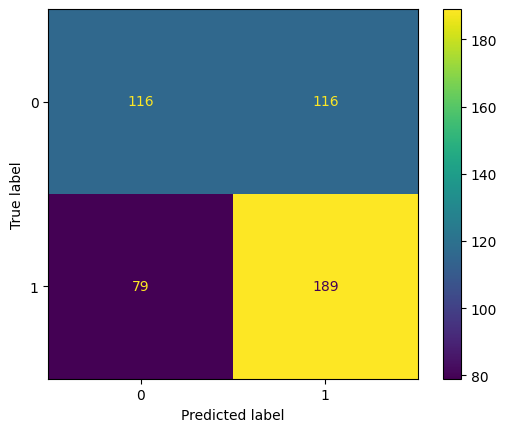

In [ ]:
y_pred_test = ridge_cv.predict(X_test_w2v)

print(classification_report(y_test, y_pred_test))

print("f1_score : ",f1_score(y_test, y_pred_test))

disp = ConfusionMatrixDisplay(confusion_matrix=confusion_matrix(y_test, y_pred_test))

disp.plot()

plt.show()

In [ ]:
def read_corpus(text, tokens_only=False):
    for i, line in enumerate(text):
        tokens = gensim.utils.simple_preprocess(line)
        if tokens_only:
            yield tokens
        else:
        # For training data, add tags
            yield gensim.models.doc2vec.TaggedDocument(tokens, [i])

train_corpus = list(read_corpus(X_train_text))
test_corpus = list(read_corpus(X_test_text, tokens_only=True))

In [ ]:
model = gensim.models.doc2vec.Doc2Vec(vector_size=50, min_count=2)
model.build_vocab(train_corpus)
model.train(train_corpus, total_examples=model.corpus_count, epochs=55)

In [ ]:
vectors = [model.infer_vector(train_corpus[doc_id].words) for doc_id in range(len(train_corpus))]
X_train_doc2vec = np.vstack(vectors)

test_vectors = [model.infer_vector(test_corpus[doc_id]) for doc_id in range(len(test_corpus))]
X_test_doc2vec = np.vstack(test_vectors)

X_train_doc2vec.shape , X_test_doc2vec.shape

((1500, 50), (500, 50))

In [ ]:
param_grid = [{'alpha':np.logspace(-2,2,20)}]
ridge_cv= GridSearchCV(RidgeClassifier(random_state=0), param_grid,cv=5)
ridge_cv.fit(X_train_doc2vec, y_train)
print("gensim doc2vec grid ridge train score ",ridge_cv.score(X_train_doc2vec, y_train))
print("gensim doc2vec grid ridge test score ",ridge_cv.score(X_test_doc2vec, y_test))
print("gensim doc2vec Ridge Classifier train mse score ",mean_squared_error(y_train,ridge_cv.predict(X_train_doc2vec)))
print("gensim doc2vec Ridge Classifier test mse score ",mean_squared_error(y_test,ridge_cv.predict(X_test_doc2vec)))
ridge_cv.best_params_

gensim doc2vec grid ridge train score  0.6326666666666667
gensim doc2vec grid ridge test score  0.63
gensim doc2vec Ridge Classifier train mse score  0.36733333333333335
gensim doc2vec Ridge Classifier test mse score  0.37


{'alpha': 100.0}

              precision    recall  f1-score   support

           0       0.70      0.35      0.47       232
           1       0.61      0.87      0.72       268

    accuracy                           0.63       500
   macro avg       0.66      0.61      0.59       500
weighted avg       0.65      0.63      0.60       500

f1_score :  0.7166921898928025


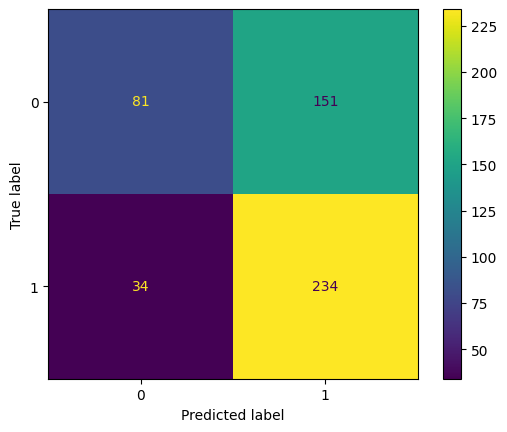

In [ ]:
y_pred_test = ridge_cv.predict(X_test_doc2vec)

print(classification_report(y_test, y_pred_test))

print("f1_score : ",f1_score(y_test, y_pred_test))

disp = ConfusionMatrixDisplay(confusion_matrix=confusion_matrix(y_test, y_pred_test))

disp.plot()

plt.show()

# Combine Text and non text features

In [ ]:
X_train_combined=pd.concat([X_train_lemma,X_train_nontext],axis=1)

X_test_combined=pd.concat([X_test_lemma,X_test_nontext],axis=1)

X_train_combined.head(5)

,parsed_code,number_of_lines,num_of_sections,token_count,variables_count,function_count,loop_count,condition_count,single_line_comment_density,function_density,loop_density,condition_density,comment_tokens_density
1740,import numpy as np\nimport pandas as pd\nfrom ...,649.0,70,452,305,21,19,11,0.197227,0.046460,0.042035,0.024336,0.449699
1477,"import os\nif not os.path.exists(""../input/tra...",122.0,16,208,80,1,5,5,0.203390,0.004808,0.024038,0.024038,0.395038
1306,import datetime\nimport warnings\nwarnings.sim...,281.0,28,363,223,4,5,6,0.064057,0.011019,0.013774,0.016529,0.083499
881,import pandas as pd\nimport numpy as np\nimpor...,215.0,32,330,167,2,0,0,0.103286,0.006061,0.000000,0.000000,0.033167
1285,import pandas as pd \nimport numpy as np\nfrom...,106.0,20,151,81,7,3,1,0.052632,0.046358,0.019868,0.006623,0.077295


In [ ]:
text_columns = categorical = X_train_combined.dtypes == object

tfidf = make_pipeline(CountVectorizer(stop_words='english', ngram_range=(2,10), min_df=100, token_pattern=custom_token_pattern),
                      Normalizer(),
                      TfidfTransformer(),memory="cache_folder")

preprocessor_combined = make_column_transformer((tfidf, 'parsed_code'),
                                                (StandardScaler(), ~text_columns),
                                               )

combine_model = Pipeline([('transformer',preprocessor_combined),
                           ('classifier',RidgeClassifier(random_state=0))])

In [ ]:
scores = cross_val_score(combine_model, X_train_combined, y_train, cv=5)
print("baseline model score: ",np.mean(scores))

baseline model score:  0.5853333333333333


In [ ]:
param_grid = [{
    'transformer__pipeline__countvectorizer__ngram_range':[(2, 5), (3, 6), (4,8), (5,9), (2,10)],
    'classifier__alpha':np.logspace(-2,2,20)}]

ridge_cv= GridSearchCV(combine_model, param_grid,cv=5,return_train_score=True)

ridge_cv.fit(X_train_combined, y_train)

print("combined grid ridge train score ",ridge_cv.score(X_train_combined, y_train))
print("combined grid ridge test score ",ridge_cv.score(X_test_combined, y_test))
print("combined Ridge classifier train mse score ",mean_squared_error(y_train,ridge_cv.predict(X_train_combined)))
print("combined Ridge classifier test mse score ",mean_squared_error(y_test,ridge_cv.predict(X_test_combined)))
ridge_cv.best_params_

combined grid ridge train score  0.6733333333333333
combined grid ridge test score  0.574
combined Ridge classifier train mse score  0.32666666666666666
combined Ridge classifier test mse score  0.426


{'classifier__alpha': 0.29763514416313175,
 'transformer__pipeline__countvectorizer__ngram_range': (4, 8)}

              precision    recall  f1-score   support

           0       0.66      0.63      0.64       697
           1       0.69      0.71      0.70       803

    accuracy                           0.67      1500
   macro avg       0.67      0.67      0.67      1500
weighted avg       0.67      0.67      0.67      1500

f1_score :  0.7008547008547008


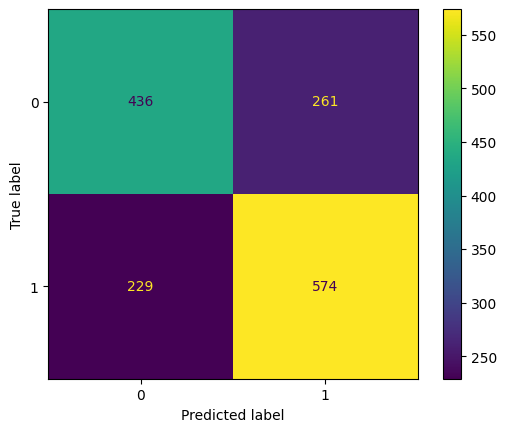

In [ ]:
y_pred_train = ridge_cv.predict(X_train_combined)

print(classification_report(y_train, y_pred_train))

print("f1_score : ",f1_score(y_train, y_pred_train))

disp = ConfusionMatrixDisplay(confusion_matrix=confusion_matrix(y_train, y_pred_train))

disp.plot()

plt.show()

              precision    recall  f1-score   support

           0       0.54      0.50      0.52       232
           1       0.60      0.64      0.62       268

    accuracy                           0.57       500
   macro avg       0.57      0.57      0.57       500
weighted avg       0.57      0.57      0.57       500

f1_score :  0.6162162162162163


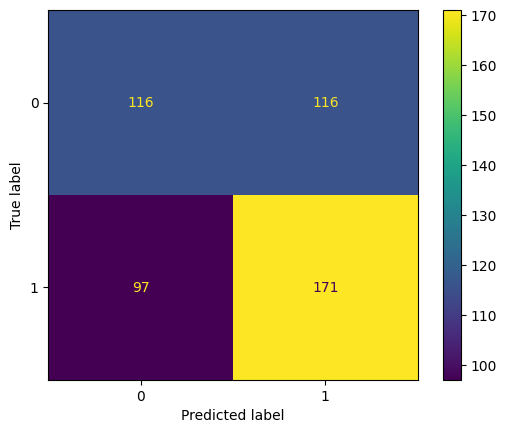

In [ ]:
y_pred_test = ridge_cv.predict(X_test_combined)

print(classification_report(y_test, y_pred_test))

print("f1_score : ",f1_score(y_test, y_pred_test))

disp = ConfusionMatrixDisplay(confusion_matrix=confusion_matrix(y_test, y_pred_test))

disp.plot()

plt.show()